# Mean Annual Precipitation of South Africa

## Introduction

This page shows a reproducible R script code of South Africa's mean annual precipitation, generated entirely from publicly available global datasets. The mean annual precipitation data is from **WorldClim**, and it can provide a wide range of ecological, hydrological, and biogeographical analyses. Rather than relying on externally oreoared shapefiles or rasters layers, I wanted to demonstrate how a scientifically interpretable map can be generated from first principles: **Data acquisition**, **spatial restriction**, **transformation**, and **visualisation**. The goal of this is not cartographic ornamentation, but to illustrate how maps can function as transparent analytical objects

## Libraries Used
The following R libraries were used in this script:
- `tidyverse` for data manipulation and visualization
- `terra` for handling, cropping, and masking of gridded climate data.
- `geodata` for accessing spatial data from **WorldClim**
- `colorspace` for constructing a sequential colour scale
- `sf` for handling spatial features


Before we begin with the analyses, I first want to prevent warning messages from appearing on my code block. *This method can be ignored when you are using RStudio or base R to do your coding. I am only using it because I am using an R kernel in Jupyter Notebook.*

In [3]:
options(warn = 1)

# Set to 0 to enable warnings
# Set to 1 to remove warnings

options(
  repr.plot.width  = 10,
  repr.plot.height = 7,
  repr.plot.res    = 150
)

# These options center our plots and gives them a better resolution than default. 
# These options are only for jupyter notebook. Ignore you use R and RStudio.

### Load libraries

In [6]:
library(terra)
library(sf)
library(geodata)
library(tidyverse)
library(colorspace)

### Data acquisition

Now that we have loaded our libraries, we must obtain the mean annual precipitation data from WorldClim via geodata. The resolution (10 arc-minutes) should be sufficient for national-scale interpretation without implying false spatial precision.

In [7]:
# Download WorldClim precipitation (mean annual)

south_africa_precipitation <- worldclim_global(
var = "prec",
res = 10,
path = tempdir()
)

# Download South Africa administrative boundary

south_africa_boundary <- geodata::gadm(
country = "ZAF",
level   = 0,
path    = tempdir()
)

# Convert boundary to sf for plotting

south_africa_boundary_sf <- st_as_sf(south_africa_boundary)

### Spatial preparation

Next we will crop and mask the global precipitation surface to South Africa. This ensures that the map does not show any information outside South Africa's boundary.

In [9]:
# Crop to bounding box

south_africa_precipitation_crop <- crop(
  south_africa_precipitation,
  south_africa_boundary
)

# Mask to country outline

south_africa_precipitation_mask <- mask(
  south_africa_precipitation_crop,
  south_africa_boundary
)

### Prepare data for plotting

`ggplot2` inside the `tidyverse` package requires a tabular structure. We will have to convert raster cells to a data frame, retaining coordinates in order to plot the data.

In [10]:
south_africa_precipitation_df <- as.data.frame(
south_africa_precipitation_mask,
xy = TRUE,
na.rm = TRUE
)

colnames(south_africa_precipitation_df) <- c(
"longitude",
"latitude",
"mean_annual_precipitation"
)

### Map Rendering

The last step is to use the data we converted into a data frame to plot our map. We will also use the colorspace package to pick the colours of the generated map. Alternatively, you could use the `viridis` package to apply colour gradients to the map (Most people use this).

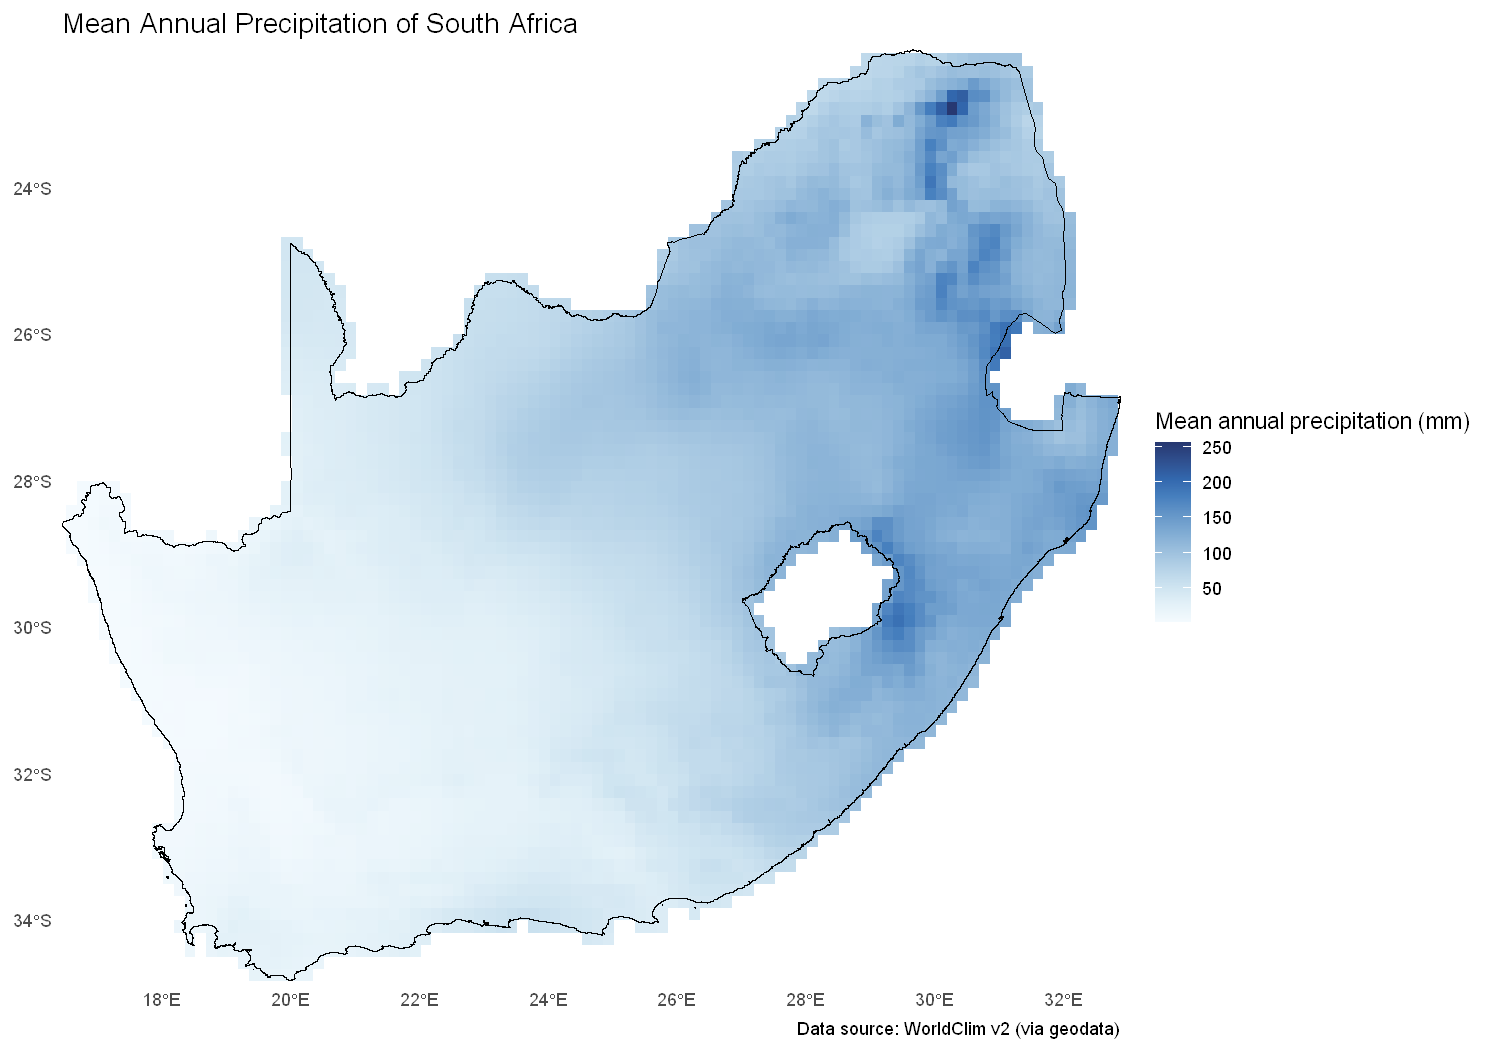

In [11]:
ggplot() +

# Add precipitation data
geom_raster( data = south_africa_precipitation_df, aes(x = longitude, y = latitude, fill = mean_annual_precipitation)) +

# Add South African boundary
geom_sf(data = south_africa_boundary_sf, fill = NA, linewidth = 0.3, colour = "black") +

# Add colour gradient to the map
scale_fill_continuous_sequential(palette = "Blues", name = "Mean annual precipitation (mm)") +

# Add map coordinates
coord_sf(expand = FALSE) +

# Add map labels
labs(title = "Mean Annual Precipitation of South Africa", caption = "Data source: WorldClim v2 (via geodata)") +

# Map themes
theme_minimal(base_size = 11) +
theme( panel.grid = element_blank(), axis.title = element_blank())

### Interpretation

What this maps shows, is the climatic gradient that structures much of South Africa's hydrology and ecology. The mean annual precipitation is lowest across the western interior and south-western parts of South Africa. It increases eastwards, and reaches its highest values along the eastern escarpmeny and the north-eastern highlands. This gradient distinguishes the arid to semi-arid systems of the Nama-Karoo and the western interior from the mesic grasslands and savanna systems further east. Having any interpretation of groundwater recharge, vegetation productivity, or surface water availability that ignores this gradient would be conceptually incomplete. 